Device: cuda


100%|██████████| 170M/170M [01:23<00:00, 2.05MB/s]


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tamaño del train: 50000
Tamaño del validation: 10000
Shape de imagen: (32, 32, 3)


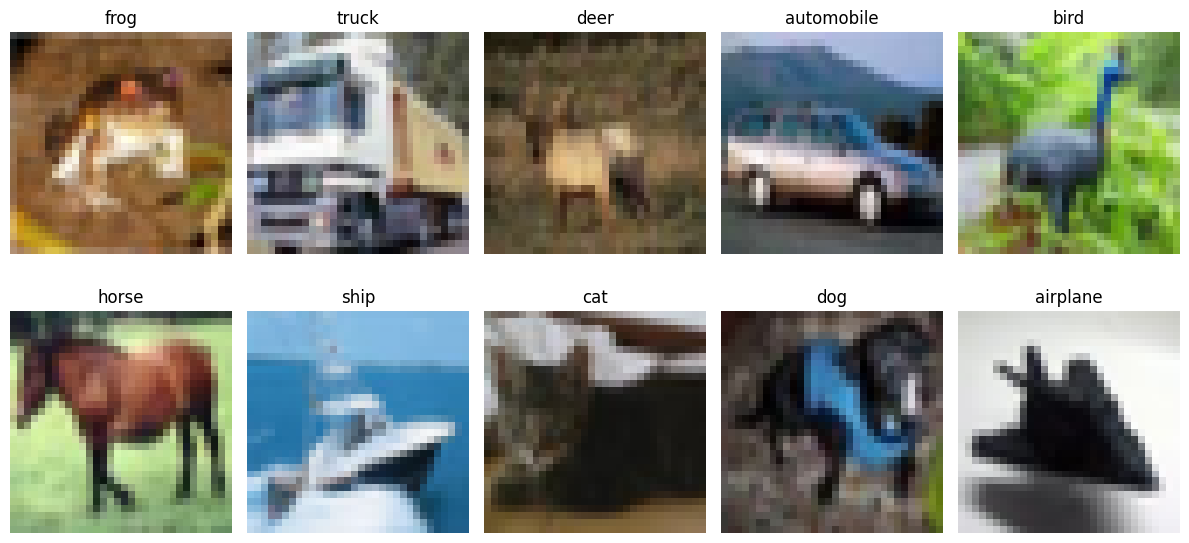

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=None
)

val_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=None
)

classes = train_dataset.classes
print("Clases:", classes)


print("Tamaño del train:", len(train_dataset))
print("Tamaño del validation:", len(val_dataset))


sample_img, sample_label = train_dataset[0]
print("Shape de imagen:", np.array(sample_img).shape)


fig, axs = plt.subplots(2, 5, figsize=(12, 6))
axs = axs.flatten()

seen = set()
shown = 0

for idx in range(len(train_dataset)):
    img, label = train_dataset[idx]
    class_name = classes[label]

    if class_name not in seen:
        seen.add(class_name)
        axs[shown].imshow(img)
        axs[shown].set_title(class_name)
        axs[shown].axis("off")
        shown += 1

        if shown == 10:
            break

plt.tight_layout()
plt.show()


batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

train_dataset.transform = train_transform
val_dataset.transform   = val_transform


In [ ]:
class SimpleCIFAR10CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCIFAR10CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCIFAR10CNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [ ]:

num_epochs = 15

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(num_epochs):

    # ---------------------------------
    # ENTRENAMIENTO
    # ---------------------------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    epoch_train_f1 = f1_score(all_labels, all_preds, average="macro")

    # ---------------------------------
    # VALIDACIÓN
    # ---------------------------------
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

            val_preds.extend(predicted.detach().cpu().numpy())
            val_labels.extend(labels.detach().cpu().numpy())

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    epoch_val_f1 = f1_score(val_labels, val_preds, average="macro")

    # guardar métricas
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)
    history["train_f1"].append(epoch_train_f1)
    history["val_f1"].append(epoch_val_f1)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f}  Val Loss: {epoch_val_loss:.4f}  "
        f"Train Acc: {epoch_train_acc:.4f}  Val Acc: {epoch_val_acc:.4f}  "
        f"Train F1: {epoch_train_f1:.4f}  Val F1: {epoch_val_f1:.4f}"
    )

#torch.save(model.state_dict(), "cifar10_cnn.pth")


Epoch [1/15] Train Loss: 1.6099  Val Loss: 1.2286  Train Acc: 0.4012  Val Acc: 0.5439  Train F1: 0.3959  Val F1: 0.5435
Epoch [2/15] Train Loss: 1.2445  Val Loss: 1.0548  Train Acc: 0.5531  Val Acc: 0.6270  Train F1: 0.5496  Val F1: 0.6172
Epoch [3/15] Train Loss: 1.0929  Val Loss: 0.9098  Train Acc: 0.6135  Val Acc: 0.6851  Train F1: 0.6108  Val F1: 0.6802
Epoch [4/15] Train Loss: 1.0020  Val Loss: 0.8416  Train Acc: 0.6497  Val Acc: 0.7050  Train F1: 0.6477  Val F1: 0.6957
Epoch [5/15] Train Loss: 0.9373  Val Loss: 0.8649  Train Acc: 0.6756  Val Acc: 0.6998  Train F1: 0.6737  Val F1: 0.6959
Epoch [6/15] Train Loss: 0.8924  Val Loss: 0.7289  Train Acc: 0.6928  Val Acc: 0.7460  Train F1: 0.6915  Val F1: 0.7442
Epoch [7/15] Train Loss: 0.8552  Val Loss: 0.7692  Train Acc: 0.7038  Val Acc: 0.7296  Train F1: 0.7022  Val F1: 0.7272
Epoch [8/15] Train Loss: 0.8188  Val Loss: 0.7380  Train Acc: 0.7152  Val Acc: 0.7411  Train F1: 0.7139  Val F1: 0.7407
Epoch [9/15] Train Loss: 0.7879  Val Los

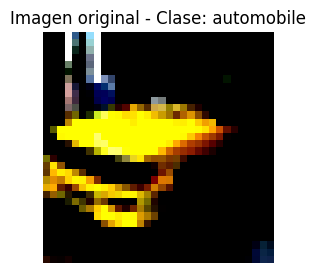


Capa convolucional 1  Shape: torch.Size([32, 32, 32])


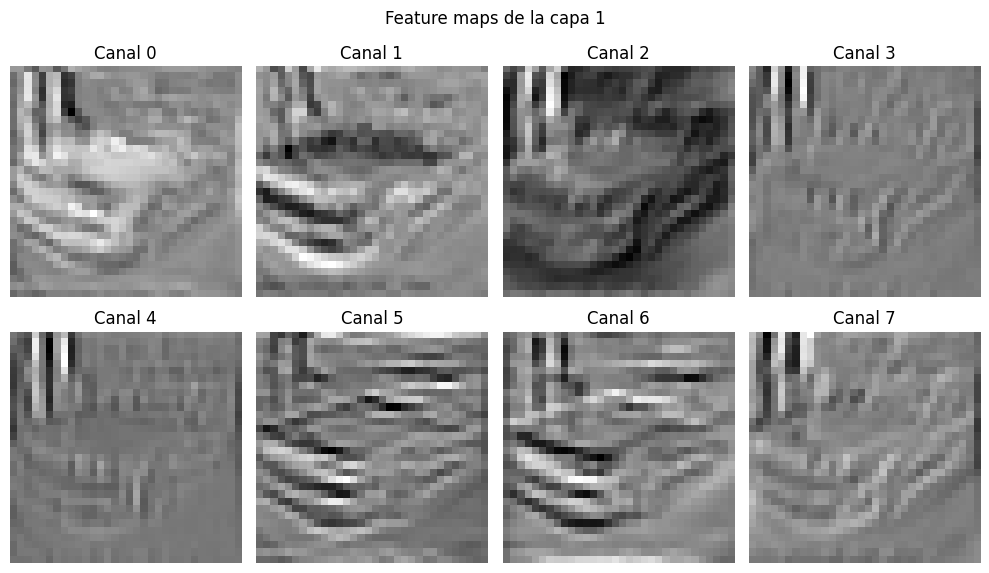


Capa convolucional 2  Shape: torch.Size([64, 16, 16])


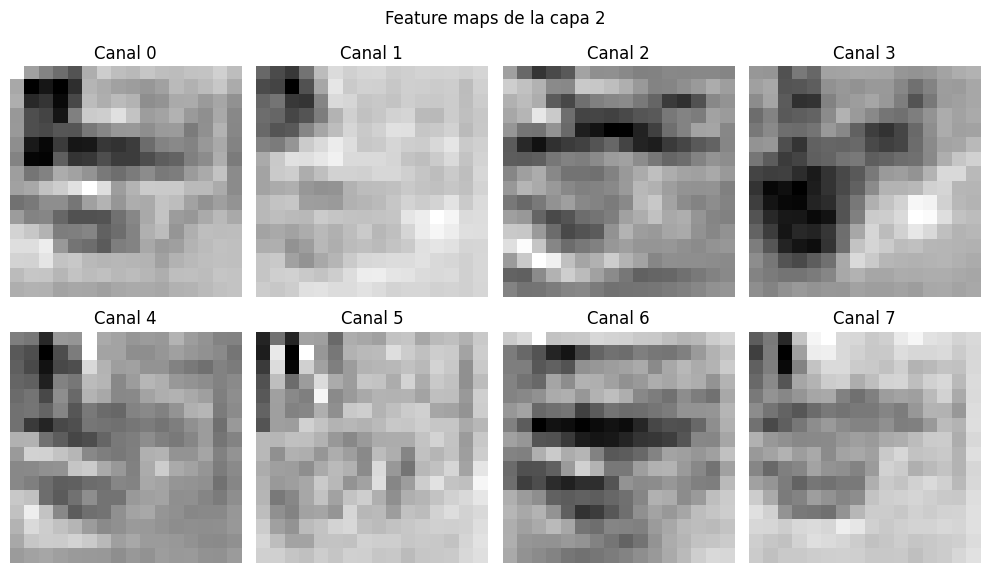


Capa convolucional 3  Shape: torch.Size([128, 8, 8])


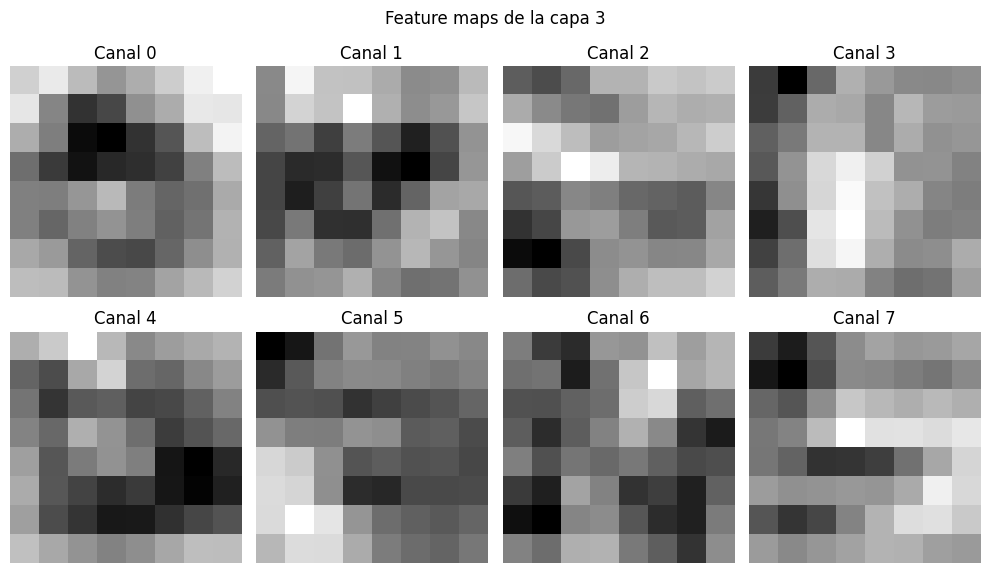

In [ ]:
import math

def mostrar_feature_maps(model, dataset, idx=0, num_maps=8):
    """
    model: tu modelo CNN
    dataset: train_dataset o val_dataset
    idx: índice de la imagen que quieres visualizar
    num_maps: cantidad de canales a mostrar por capa
    """

    model.eval()

    # obtener imagen
    img, label = dataset[idx]
    img_input = img.unsqueeze(0).to(device)

    # mostrar imagen original
    plt.figure(figsize=(3, 3))
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(f"Imagen original - Clase: {classes[label]}")
    plt.axis("off")
    plt.show()

    # obtener activaciones de las capas convolucionales
    activaciones = []
    x = img_input

    for layer in model.features:
        x = layer(x)
        if isinstance(layer, nn.Conv2d):
            activaciones.append(x.detach().cpu())

    # mostrar feature maps por capa
    for layer_idx, fmap in enumerate(activaciones):
        fmap = fmap.squeeze(0)
        channels = fmap.shape[0]

        print(f"\nCapa convolucional {layer_idx + 1}  Shape: {fmap.shape}")

        n = min(num_maps, channels)
        cols = 4
        rows = math.ceil(n / cols)

        fig, axs = plt.subplots(rows, cols, figsize=(10, 6))
        axs = axs.flatten()

        for i in range(n):
            axs[i].imshow(fmap[i], cmap="gray")   # escala de grises
            axs[i].set_title(f"Canal {i}")
            axs[i].axis("off")

        for i in range(n, len(axs)):
            axs[i].axis("off")

        plt.suptitle(f"Feature maps de la capa {layer_idx + 1}")
        plt.tight_layout()
        plt.show()


mostrar_feature_maps(model, val_dataset, idx=1006, num_maps=8)


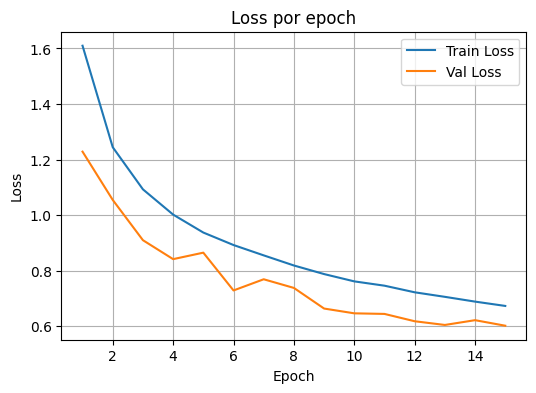

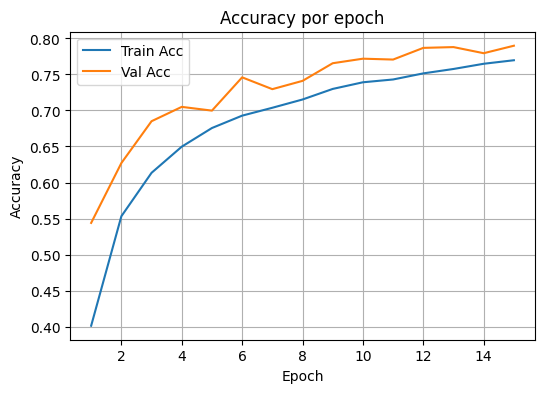

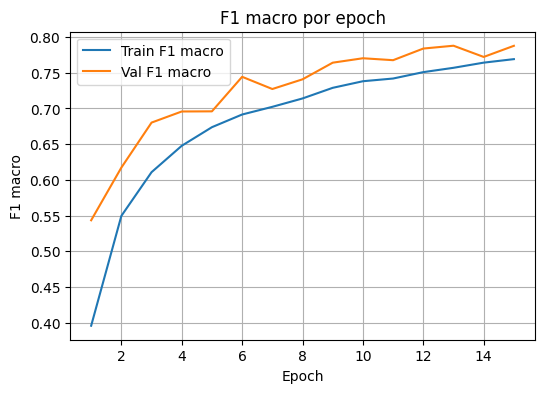

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy por epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_f1"], label="Train F1 macro")
plt.plot(epochs, history["val_f1"], label="Val F1 macro")
plt.xlabel("Epoch")
plt.ylabel("F1 macro")
plt.title("F1 macro por epoch")
plt.legend()
plt.grid(True)
plt.show()



Predicción: frog (97.27 %)


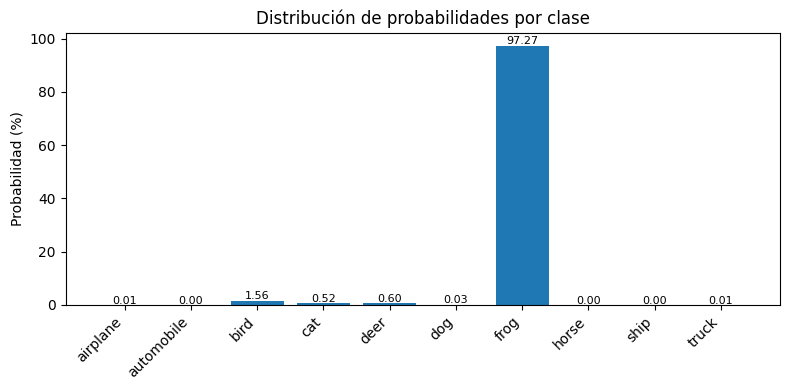

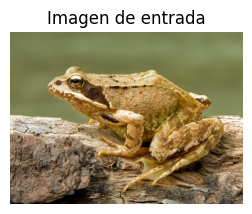

In [ ]:
from PIL import Image

inference_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std)
])

def infer_image(path_img, model, classes):
    model.eval()
    img = Image.open(path_img).convert("RGB")
    x = inference_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    predicted_idx = int(np.argmax(probs))
    predicted_class = classes[predicted_idx]

    print(f"Predicción: {predicted_class} ({probs[predicted_idx] * 100:.2f} %)")

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(len(classes)), probs * 100)
    plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
    plt.ylabel("Probabilidad (%)")
    plt.title("Distribución de probabilidades por clase")

    for i, p in enumerate(probs * 100):
        plt.text(i, p + 0.5, f"{p:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Imagen de entrada")
    plt.show()


# Ejemplo:
infer_image("rana.jpg", model, classes)
